In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import roc_auc_score
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, LSTM, Masking, Input, GRU, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from tensorflow.keras import regularizers
from sklearn.utils import shuffle
from qkeras import *
import qkeras
from tensorflow.keras.models import load_model
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights

import hls4ml

import os

2026-04-28 15:45:30.094409: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-28 15:45:32.727138: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## GRU

In [3]:
def grumodel(max_len, n_var, rec_units, ndense=[50, 10], l1_reg=0,
              l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
             dense_kernel_init='lecun_uniform'):
    
    hidden = x_in = Input(shape=(max_len, n_var,))
    hidden = GRU(units=rec_units,
                  recurrent_activation = rec_act,
                  kernel_initializer = rec_kernel_init, 
                  name = 'gru')(hidden)
    
    hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
    hidden = Activation('relu', name = 'relu_0')(hidden)
    
    hidden = Dense(10, kernel_initializer=dense_kernel_init, name='dense_1' )(hidden)
    hidden = Activation('relu', name = 'relu_1')(hidden)

    hidden = Dense(3, kernel_initializer=dense_kernel_init, name = 'dense_2')(hidden)
    hidden = Activation('softmax', name = 'output_softmax')(hidden)
    
    model = Model(inputs=x_in, outputs=hidden)
    
    return model

In [4]:
# def nongrumodel(max_len, n_var, rec_units, ndense=[50, 10], l1_reg=0,
#               l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
#              dense_kernel_init='lecun_uniform'):
    
#     hidden = x_in = Input(shape=(max_len, n_var,))
    
#     #hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
#     hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
#     hidden = Activation('relu', name = 'relu_0')(hidden)
    
#     hidden = Dense(10, kernel_initializer=dense_kernel_init, name='dense_1' )(hidden)
#     hidden = Activation('relu', name = 'relu_1')(hidden)

#     hidden = Dense(3, kernel_initializer=dense_kernel_init, name = 'dense_2')(hidden)
#     hidden = Activation('softmax', name = 'output_softmax')(hidden)
    
#     model = Model(inputs=x_in, outputs=hidden)
    
#     return model

## Floating Point Model Training

In [5]:
l1_reg = 0
l2_reg = 0

## GRU full model

## GRU Model
model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

## LSTM Model
#model = lstmmodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

model.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])

## nongru model
#nogru_model = nongrumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
#nogru_model = nongrumodel(50, 120, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
#nogru_model.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])  

model_output = 'gru_test3/gru.h5'

train = False
if train:
    history = model.fit(x_train, y_train,
            batch_size=2**10,
            epochs=150,
            validation_data=(x_val, y_val), 
            shuffle = True,
            sample_weight= w_train,
            callbacks = [
                EarlyStopping(verbose=True, patience=20, monitor='val_accuracy'),
                ModelCheckpoint(model_output, monitor='val_accuracy', verbose=True, save_best_only=True)
                ],
            verbose=True
            )
#y_keras = model.predict(x_test, batch_size=2**10)
#auc_score = roc_auc_score(y_test, y_keras)
#print("AUC score:", auc_score)

2026-04-28 15:46:06.065324: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
# Pruning model
#from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
#from tensorflow_model_optimization.sparsity.keras import strip_pruning

#pruning_params = {"pruning_schedule": pruning_schedule.ConstantSparsity(0.75, begin_step=2000, frequency=100)}
#model = prune.prune_low_magnitude(model, **pruning_params)

## GRU weight

In [7]:
##model = load_model("./gru_test3/gru_weights.h5", custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})

modelimport = load_model("./gru_test3/gru_weights.h5", custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})

# weights only, any errors from loading weights 
model.load_weights("./gru_test3/gru_floating.weights.h5", by_name=True) #, skip_mismatch=True
#model.save_weights("./gru_test3/gru_floating.weights.h5")

print("model import")
modelimport.summary()

print("model")
model.summary()

#2int_qgru_test3/4frac_qgru_weights
for layer in model.layers:
    weights = layer.get_weights()
    print(layer.name, weights)
    print(layer.name, layer.get_config())

model import
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 15, 6)]           0         
                                                                 
 gru (GRU)                   (None, 120)               46080     
                                                                 
 dense_0 (Dense)             (None, 50)                6050      
                                                                 
 relu_0 (Activation)         (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                510       
                                                                 
 relu_1 (Activation)         (None, 10)                0         
                                                                 
 dense_2 (Dense)             (None, 3)          

In [7]:
# ## no gru weight load, dense0 nooooooooo dense0 mismatch, 
# # the change in dimensions is correct since the dinemensions of the gru determine input dimensions

# nogru_model.load_weights("./gru_test3/gru_floating.weights.h5", skip_mismatch=True, by_name=True) 


# #for gru_layer in model.layers:
# #    gru_weights = gru_layer.get_weights()
# #    for nogru_layer in nogru_model.layers:
# #        if (gru_layer.name = nogru_layer.name):
# #            nogru_model.layer.set_weights(weights)

# #weights_list = model.get_weights() #causes issues

# #print(model.layers[0].name, model.layers[0].get_weights()) # input
# #nogru_model.layers[0].set_weights(model.layers[0].get_weights())

# #print(model.layers[1].name, model.layers[1].get_weights()) # gru

# #print(model.layers[2].name, model.layers[2].get_weights()) # dense0
# #nogru_model.layers[1].set_weights(model.layers[2].get_weights())

# #nogru_model.layers[1].set_weights(weights_list[3])
# #for i, weights in enumerate(weights_list[2:7]):
# #    print(model.layers[0].name, weights_list[0])
# #    print(nogru_model.layers[0].name)
# #    print(nogru_model.layers[i+1].name)
# #    nogru_model.layers[i+1].set_weights(weights)

# print("nogru model")
# nogru_model.summary()

# # loading weights by layer to confirm it actually work
# for layer in nogru_model.layers:
#     weights = layer.get_weights()
#     print(layer.name, weights)

## Load QGRU Post Training Weights

In [8]:

#from qkeras.utils import model_quantize

#l1_reg = 0
#l2_reg = 0

### GRU Model
#model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

## new_GRU_0int = []
## new_GRU_1int = []
## new_GRU_4int = []
## GRU_1int = []
#for int_bits in [0]:
#    for i in [1]:
#        total_bits = i + int_bits + 1
#        config = {
#            "QGRU":{
#                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
#                 "bias_quantizer" : f"quantized_bits({total_bits}, {int_bits},1)",
#                 "recurrent_quantizer": f"quantized_bits({total_bits},{int_bits},1)",
#                 "state_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
#            },
#            "QDense":{
#                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
#                "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
#            },
#            "relu_0" : f"quantized_relu({total_bits},{int_bits},1)",
#            "relu_1" : f"quantized_relu({total_bits},{int_bits},1)",
#        }
#    
#        qmodel = model_quantize(model, config, total_bits, transfer_weights=True)
    
# for layer in qmodel.layers:
#         if hasattr(layer, "recurrent_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal), 
#                     "recurrent:", str(layer.recurrent_quantizer_internal), "state:", str(layer.state_quantizer_internal))
#         elif hasattr(layer, "kernel_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal))
#         elif hasattr(layer, "quantized_relu"):
#             print(layer.name, "quantized_relu:", str(layer.quantizer))
#         else:
#             print(layer.name)
                
#        qmodel.summary()
    
#        qmodel.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])
    

In [9]:

#model =  load_model('gru_test3/gru_weights.h5')

#model.load_weights('4int_qgru_test3/2frac_qgru_weights.h5')
#model = load_model('4int_qgru_test3/2frac_qgru_weights.h5', custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})


#qgru = load_model('4int_qgru_test3/2frac_qgru_weights.h5', custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})


#model_save_quantized_weights(qgru, f"ptq2int2fra_weight")

### Synthesis of Model

In [ ]:
#import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='model')
#config = hls4ml.utils.config_from_keras_model(model, granularity='model')
                                # backend='Vivado' #granularity = 'name' #granularity = 'model' 
                                # default_precision='ap_fixed<16,6>' # default_reuse_factor=2
config['Model']['ReuseFactor'] = 1000000 #9 #8 #4096 #16 #24 #16 #4 #1 #28 #0000 #10 is min #5
# config['Model']['IOType'] = 'io_stream'
#config['Model']['IOType'] = 'io_parallel'
config['Model']['Strategy'] = 'resource'  #stable
config['Model']['Precision'] = 'ap_fixed<16,6>' #'ap_fixed<7,3>' #'ap_fixed<16,6>' # ap_fixed<6,2> // 1 sign, 1 int, 4 frac

#config['LayerName']['output_softmax']['implementation'] = 'argmax'

config['Flows'] = ['vivado:fifo_depth_optimization']

hls4ml.model.optimizer.get_optimizer('vivado:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

#print("-----------------------------------")
#print("Configuration")
#plotting.print_dict(config) 
#print("-----------------------------------")

output = 'gru_test3_fifoop_16_6_reuse1000000_bigboard_stream'

#creating hls model using 'Vivado'
backendSynth = 'Vivado' #vitis'
hls_model = hls4ml.converters.convert_from_keras_model(
    model, 
    hls_config=config, 
    backend=backendSynth, 
    output_dir=(f'models/gru_floating_point/{output}/hls4ml_prj'), #fifoop_
    ##part='xcu250-figd2104-2L-e',
    #part='xc7vx690tffg1761-2'
    #part='xcu280-fsvh2892-2L-e'
    part='xcvu13p-fhga2104-3-e',
    io_type='io_stream'
    #io_type='io_parallel'
) 
#vitis #models/vitis/gru_floating_point/gru_test3/hls4ml_prj 
#Vivado # models/gru_floating_point/gru_test3/hls4ml_prj
# #models/qgru_4int/2frac_model_qgru/hls4ml_prj
# models/gru_floating_point/gru_4_2_test3/hls4ml_prj
# models/gru_floating_point/gru_test3_middleBoard_reuse4096/hls4ml_prj

#qkeras
#models/gru_2int/gru_4frac_largeBoard_reuse4096/hls4ml_prj


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2019.1 (64-bit)
  **** SW Build 2552052 on Fri May 24 14:47:09 MDT 2019
  **** IP Build 2548770 on Fri May 24 18:01:18 MDT 2019
    ** Copyright 1986-2019 Xilinx, Inc. All Rights Reserved.

source /tools/Disk_Xilinx/Vivado/2019.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Disk_Xilinx/Vivado/2019.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'quin' on host 'hvm1' (Linux_x86_64 version 5.15.0-174-generic) on Wed Apr 22 19:51:13 PDT 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/models/gru_floating_point/gru_test3_fifoop_16_6_reuse1000000_bigboard_stream/hls4ml_prj'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Opening project '/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/models/gru_floating_point/gru_test3_fifoop_16_6_reuse1000000_bigboard_stream

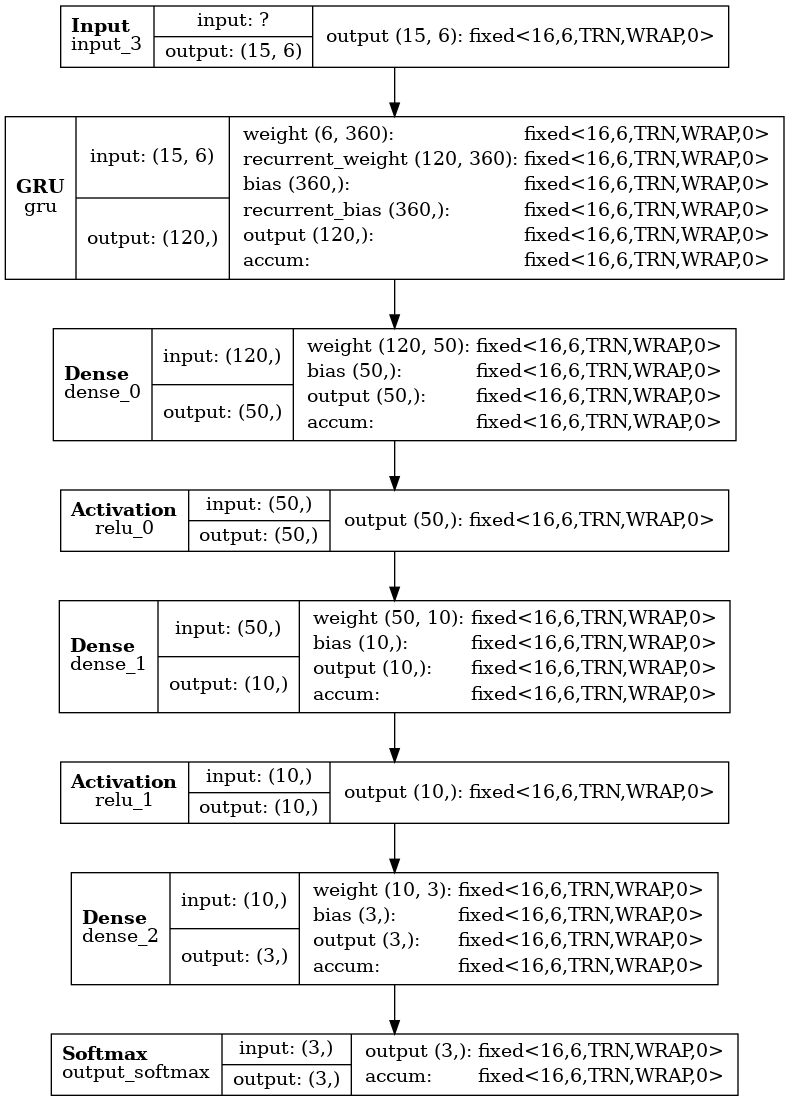

In [ ]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [ ]:
# build the model using HLS
hls_model.build(csim=False) #

# remember to change hls_script to pull from the right file
###os.system(f"vivado -mode batch -source hls_script.tcl")

#os.system(f"vivado -mode batch -source hls_script.tcl -tclargs {name}")

#os.makedirs(f'/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/reports/{output}', exist_ok=True)
#file_path_report = (f'/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/reports/{output}/_util.rpt')

###error=f"HLS4ML Script Completed"
###if os.path.exists(file_path_report):
###    os.system(f'printf "Completed building HLS model using {backendSynth}, no errors" | mail -s "{error}" ljdono@uw.edu') 
###else:
###    error=f"HLS4ML Script Completed"
###    os.system(f'printf "Couldnt complete building HLS model using {backendSynth}, errored out" | mail -s "{error}" ljdono@uw.edu') 

error=f"HLS Script Completed"
os.system(f'printf "Complete building HLS model using {backendSynth}, no routing using {backendSynth}" | mail -s "{error}" ljdono@uw.edu') 

#os.system(f'printf "Completed building HLS model using {backendSynth}" | mail -s "{error}" ljdono@uw.edu') 


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2019.1 (64-bit)
  **** SW Build 2552052 on Fri May 24 14:47:09 MDT 2019
  **** IP Build 2548770 on Fri May 24 18:01:18 MDT 2019
    ** Copyright 1986-2019 Xilinx, Inc. All Rights Reserved.

source /tools/Disk_Xilinx/Vivado/2019.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Disk_Xilinx/Vivado/2019.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'quin' on host 'hvm1' (Linux_x86_64 version 5.15.0-174-generic) on Thu Apr 09 14:54:23 PDT 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/models/gru_floating_point/gru_test3_16_6_reuse1000000_bigboard_stream/hls4ml_prj'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/models/gru_floating_point/gru_test3_16_6_reuse1000000_bigboard_stream/

0